# End-to-End Generative Evaluation

This notebook performs the final evaluation of the San Diego Land Use RAG system. While the Stage 09 notebook focused on retrieval precision (MRR, Hit Rate), this stage evaluates the entire pipeline, from retrieval through response generation, using both deterministic and LLM-based metrics.

### Evaluation Metrics
1. **ROUGE-L**: Measures the longest common subsequence overlap between the generated answer and the ground truth source text.
2. **BERTScore**: Measures the semantic similarity between the generated answer and the ground truth source text using contextual embeddings.
3. **Faithfulness (Hallucination Detection)**: An LLM judge evaluates whether the generated answer is strictly grounded in the retrieved context or contains fabricated information.

### Architecture
This notebook is designed for native execution on **Google Colab** with a T4 GPU. The Ollama daemon and Phi-4 Mini model handle both response generation and faithfulness judging, maintaining consistency with the methodology established in Stage 08.

**This notebook is recommended to run on Google Colab with a GPU (T4 or higher).**

## 1. Environment Setup and Drive Mount
Install all required dependencies and initialize the Ollama daemon for local LLM inference.

In [1]:
# Install dependencies
!pip install sentence-transformers pandas rouge-score bert-score tqdm -q

# Install and start Ollama daemon
!apt-get update -qq && apt-get install -y -qq zstd
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time

process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)
print("Ollama daemon started.")

# Pull the Phi-4 Mini model
!ollama pull phi4-mini
print("Phi-4 Mini model loaded successfully.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install comple

In [2]:
import os
import json
import requests
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from datasets import Dataset
from sentence_transformers import SentenceTransformer, InputExample, losses, util
from torch.utils.data import DataLoader
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Paths
if IN_COLAB:
    base_path = '/content/drive/MyDrive/sd-land-use-rag'
else:
    base_path = '..'

ground_truth_path = f"{base_path}/data/processed/evaluation_ground_truth.json"
chunks_path = f"{base_path}/data/processed/san_diego_code_chunks.jsonl"
mlm_model_path = f"{base_path}/models/san_diego_legal_bert"

print(f"Base path: {base_path}")
print(f"Ground truth exists: {os.path.exists(ground_truth_path)}")
print(f"Chunks exist: {os.path.exists(chunks_path)}")
print(f"MLM model exists: {os.path.exists(mlm_model_path)}")

Mounted at /content/drive
Base path: /content/drive/MyDrive/sd-land-use-rag
Ground truth exists: True
Chunks exist: True
MLM model exists: True


## 2. Data Loading
Load the 50-query ground truth dataset and the full municipal code corpus.

In [3]:
# Load evaluation queries
with open(ground_truth_path, 'r') as f:
    evaluation_data = json.load(f)
print(f"Loaded {len(evaluation_data)} evaluation queries.")

# Load full corpus
corpus = []
with open(chunks_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        corpus.append(data['text'])
print(f"Loaded {len(corpus)} corpus documents.")

Loaded 50 evaluation queries.
Loaded 52384 corpus documents.


## 3. Retriever Initialization
The MLM-adapted Legal-BERT model is loaded and then fine-tuned inline using Contrastive Loss (MultipleNegativesRankingLoss). This replicates the Stage 07b pipeline to produce a fully self-contained evaluation environment. Since the training set contains only 50 pairs, this step completes in seconds even on CPU.

In [4]:
# Build contrastive training examples from the ground truth
train_examples = []
for item in evaluation_data:
    train_examples.append(InputExample(texts=[item['query'], item['source_text']]))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)

# Load MLM model and apply contrastive fine-tuning
print("Loading MLM-adapted Legal-BERT and applying contrastive fine-tuning...")
retrieval_model = SentenceTransformer(mlm_model_path)
train_loss = losses.MultipleNegativesRankingLoss(model=retrieval_model)

retrieval_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=10,
    warmup_steps=5,
    show_progress_bar=True
)
print("Contrastive fine-tuning complete.")

# Embed the full corpus
print("Embedding corpus (this may take 1-2 minutes)...")
corpus_embeddings = retrieval_model.encode(corpus, convert_to_tensor=True, show_progress_bar=True)
print(f"Corpus embeddings shape: {corpus_embeddings.shape}")

Loading MLM-adapted Legal-BERT and applying contrastive fine-tuning...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /content/drive/MyDrive/sd-land-use-rag/models/san_diego_legal_bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


Contrastive fine-tuning complete.
Embedding corpus (this may take 1-2 minutes)...


Batches:   0%|          | 0/1637 [00:00<?, ?it/s]

Corpus embeddings shape: torch.Size([52384, 768])


## 4. End-to-End RAG Pipeline Execution
For each evaluation query, the retriever fetches the top-5 most relevant document chunks. These chunks are then passed alongside the query to Phi-4 Mini, which generates a natural language answer. This simulates the full production RAG experience.

In [5]:
OLLAMA_URL = "http://localhost:11434/api/generate"

def retrieve_top_k(query, k=5):
    """Retrieve the top-k corpus chunks for a given query."""
    query_embedding = retrieval_model.encode(query, convert_to_tensor=True)
    hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=k)[0]
    return [corpus[hit['corpus_id']] for hit in hits]

def generate_answer(query, context_chunks):
    """Generate an answer using Phi-4 Mini via Ollama, given a query and retrieved context."""
    context_block = "\n\n---\n\n".join(context_chunks)
    prompt = (
        f"Given the following regulatory context from the San Diego Municipal Code, "
        f"answer the question accurately and concisely. If the answer cannot be "
        f"determined from the provided context, state that explicitly.\n\n"
        f"Context:\n{context_block}\n\n"
        f"Question: {query}\n\n"
        f"Answer:"
    )
    try:
        response = requests.post(OLLAMA_URL, json={
            "model": "phi4-mini",
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.1, "num_predict": 300}
        }, timeout=120)
        return response.json().get('response', '').strip()
    except Exception as e:
        print(f"Generation error: {e}")
        return ""

In [6]:
results = []

print("Running end-to-end RAG pipeline on 50 evaluation queries...")
for item in tqdm(evaluation_data):
    query = item['query']
    ground_truth_text = item['source_text']

    # Retrieve
    retrieved_chunks = retrieve_top_k(query, k=5)

    # Generate
    generated_answer = generate_answer(query, retrieved_chunks)

    results.append({
        'query_id': item['query_id'],
        'query': query,
        'ground_truth_text': ground_truth_text,
        'retrieved_context': retrieved_chunks,
        'generated_answer': generated_answer
    })

print(f"Generated answers for {len(results)} queries.")

Running end-to-end RAG pipeline on 50 evaluation queries...


  0%|          | 0/50 [00:00<?, ?it/s]

Generated answers for 50 queries.


## 5. Deterministic Evaluation Metrics
Two standard NLP evaluation metrics are computed to measure the quality of the generated answers against the ground truth source text.

- **ROUGE-L**: Captures the longest common subsequence between the generated and reference texts, reflecting structural overlap.
- **BERTScore**: Uses contextual embeddings to measure semantic similarity, accounting for paraphrasing and synonymy.

In [7]:
# ROUGE-L Evaluation
print("Computing ROUGE-L scores...")
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

rouge_scores = []
for r in results:
    score = scorer.score(r['ground_truth_text'], r['generated_answer'])
    rouge_scores.append(score['rougeL'].fmeasure)

mean_rouge = np.mean(rouge_scores)
print(f"Mean ROUGE-L F1: {mean_rouge:.4f}")

Computing ROUGE-L scores...
Mean ROUGE-L F1: 0.2024


In [8]:
# BERTScore Evaluation
print("Computing BERTScore (this may take a moment)...")
generated_answers = [r['generated_answer'] for r in results]
reference_texts = [r['ground_truth_text'] for r in results]

P, R, F1 = bert_score_fn(generated_answers, reference_texts, lang='en', verbose=True)

mean_bertscore = F1.mean().item()
print(f"Mean BERTScore F1: {mean_bertscore:.4f}")

Computing BERTScore (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 3.18 seconds, 15.75 sentences/sec
Mean BERTScore F1: 0.8493


## 6. Faithfulness Evaluation (Hallucination Detection)
Phi-4 Mini is used as an automated judge to evaluate whether each generated answer is strictly grounded in the retrieved context. The model assigns a score from 0.0 (completely hallucinated) to 1.0 (fully faithful).

In [17]:
import re

SCORE_MAP = {1: 0.0, 2: 0.25, 3: 0.5, 4: 0.75, 5: 1.0}

def judge_faithfulness(answer, context_chunks):
    """Use Phi-4 Mini to evaluate whether the answer is grounded in the context."""
    context_block = "\n\n".join(context_chunks)
    prompt = (
        "You are a faithfulness evaluator. Determine if the answer "
        "is supported by the given context.\n\n"
        f"Context:\n{context_block}\n\n"
        f"Answer:\n{answer}\n\n"
        "Rate the faithfulness on a scale of 1 to 5:\n"
        "1 = Completely fabricated\n"
        "2 = Mostly fabricated\n"
        "3 = Partially faithful\n"
        "4 = Mostly faithful\n"
        "5 = Fully faithful\n\n"
        "Respond with ONLY a single number (1, 2, 3, 4, or 5):"
    )
    try:
        response = requests.post(OLLAMA_URL, json={
            "model": "phi4-mini",
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.0, "num_predict": 50}
        }, timeout=60)
        raw = response.json().get('response', '').strip()

        # Primary: extract a digit 1-5
        match = re.search(r'\b([1-5])\b', raw)
        if match:
            return SCORE_MAP[int(match.group(1))]

        # Fallback: keyword-based scoring from conversational responses
        lower_raw = raw.lower()
        if 'fully' in lower_raw or 'entirely accurate' in lower_raw:
            return 1.0
        elif 'mostly faithful' in lower_raw or 'high' in lower_raw:
            return 0.75
        elif 'partially' in lower_raw:
            return 0.5
        elif 'mostly fabricated' in lower_raw or 'inaccurate' in lower_raw:
            return 0.25

        print(f"  [DEBUG] Could not parse score from: '{raw[:80]}'")
        return 0.0
    except Exception as e:
        print(f"Faithfulness judging error: {e}")
        return 0.0


In [18]:
print("Running faithfulness evaluation on generated answers...")
faithfulness_scores = []
for r in tqdm(results):
    score = judge_faithfulness(r['generated_answer'], r['retrieved_context'])
    faithfulness_scores.append(score)

mean_faithfulness = np.mean(faithfulness_scores)
print(f"Mean Faithfulness Score: {mean_faithfulness:.4f}")

Running faithfulness evaluation on generated answers...


  0%|          | 0/50 [00:00<?, ?it/s]

Mean Faithfulness Score: 0.7350


## 7. Final System Scorecard
Aggregating all evaluation dimensions into a single summary table.


================ FINAL GENERATIVE EVALUATION ================

        Metric    Score
  ROUGE-L (F1) 0.202426
BERTScore (F1) 0.849296
  Faithfulness 0.735000




/tmp/ipykernel_3838/1641907698.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scorecard, x='Metric', y='Score', palette='viridis', ax=ax)


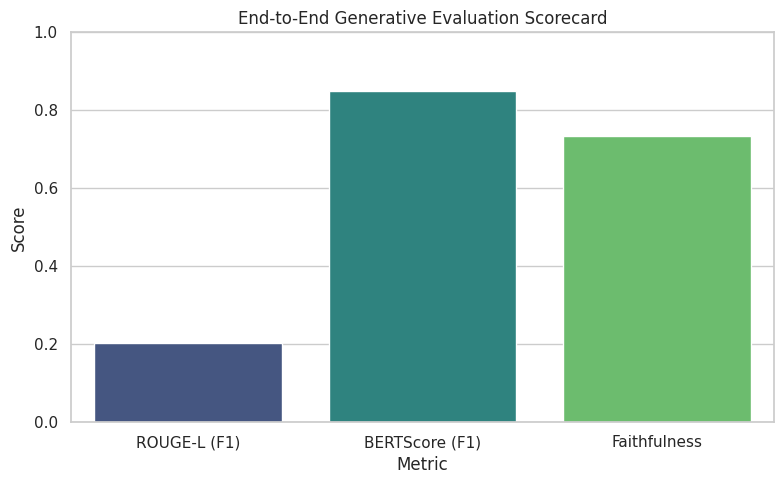

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

scorecard = pd.DataFrame({
    'Metric': ['ROUGE-L (F1)', 'BERTScore (F1)', 'Faithfulness'],
    'Score': [mean_rouge, mean_bertscore, mean_faithfulness]
})

print("\n================ FINAL GENERATIVE EVALUATION ================\n")
print(scorecard.to_string(index=False))
print("\n=============================================================\n")

# Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=scorecard, x='Metric', y='Score', palette='viridis', ax=ax)
ax.set_title('End-to-End Generative Evaluation Scorecard')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [20]:
# Save detailed results for inclusion in the Capstone Report
output_path = f"{base_path}/data/processed/generative_evaluation_results.json"

export_data = []
for i, r in enumerate(results):
    export_data.append({
        'query_id': r['query_id'],
        'query': r['query'],
        'generated_answer': r['generated_answer'],
        'rouge_l': rouge_scores[i],
        'bertscore_f1': F1[i].item(),
        'faithfulness': faithfulness_scores[i]
    })

with open(output_path, 'w') as f:
    json.dump(export_data, f, indent=2)

print(f"Detailed results saved to: {output_path}")

Detailed results saved to: /content/drive/MyDrive/sd-land-use-rag/data/processed/generative_evaluation_results.json
